# Variability

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [27]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats as ss
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = '/lhome/nicholas/software/workdir/mocka'
idir = f'{path}/input'
vdir = '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim'

## Synthetic SEDs for VarSim

In [11]:
# Valid paramter space for PHOENIX spectra
valid_t_phoenix = np.array([*list(range(2300, 7000, 100)), 
                            *list((range(7000, 12200, 200)))])
valid_g_phoenix = np.array([*list(np.arange(0, 6, 0.5))])

# Valid parameter space for ATLAS9 spectra
valid_t_atlas9 = np.array([*list(range(3000, 1300, 250)), 
                           *list((range(13000, 50000, 1000)))])

<IPython.core.display.Javascript object>


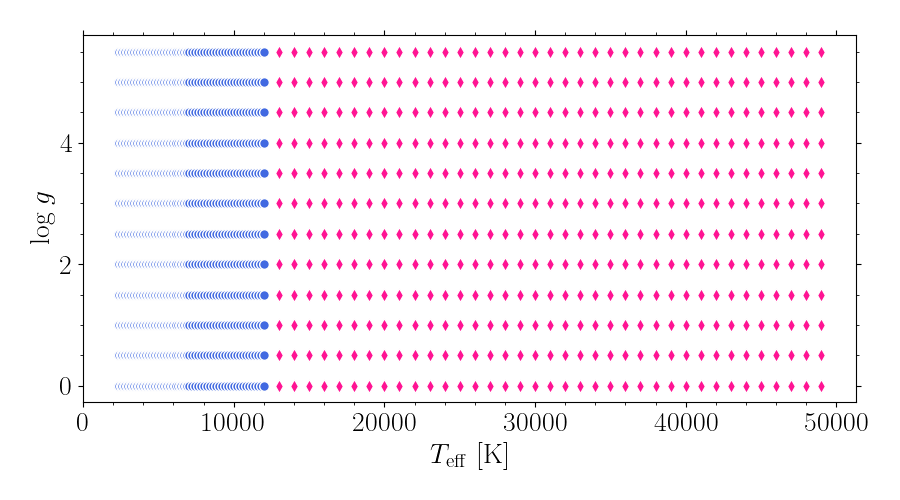

In [12]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for i in range(len(valid_g_phoenix)):
    ax.plot(valid_t_phoenix, np.ones_like(valid_t_phoenix)*valid_g_phoenix[i], 
            'o', c='royalblue', mec='w', ms=7)
    ax.plot(valid_t_atlas9,  np.ones_like(valid_t_atlas9)*valid_g_phoenix[i], 
            'd', c='deeppink', mec='w', ms=7)
    
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel('log $g$')
plt.tight_layout()

---
## $\gamma$ Doradus- stars (Gang+2020)
---

### Modes in period-spacing pattern

In [242]:
# Units: freq [], ampl []
filenames_all = glob.glob(f'{vdir}/varsource_gdor_gang2020/*.dat')
filenames = glob.glob(f'{vdir}/varsource_gdor_gang2020_pattern/*')
N = len(filenames)

dm = pd.DataFrame()
da = pd.DataFrame()
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
n_off = np.zeros(N)

# Loop over each star
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    starfiles = glob.glob(f'{f}/*')
        
    # For each star check each file 
    for s in starfiles:

        # Load only dipole sectoral modes (l,m)=(1,1)
        if s[-18:-15] == 'k=0' and s[-14:-11] == 'm=1': 
            dv_i = pd.read_csv(s, sep=' ', skiprows=1, names=['per', 'per_err'])
            
            # Remove mising modes and store periods
            dm_i = dv_i[~(dv_i.per == 9999.0)]
            dm = pd.concat([dm, dm_i])   
            
            # Number of modes (including missing ones)
            N_mod[i] = dm_i.shape[0]
            
            # First period in pattern [days]
            P0[i] = dm_i.per.iloc[0]
            
            # Calculate period spacings [days]
            n = int(dv_i.shape[0])-1
            dx = pd.DataFrame()
            dx['delta_P'] = dv_i.per.diff().dropna()
            dx['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
            # Remove undefined modes
            dx = dx[~(dx.delta_P.abs() > 10) & ~(dx.delta_P.abs() == 0.0)]
            
            # First period spacing
            dP0[i] = dx.delta_P.iloc[0]
            
            # Fit and find slope
            coeff = np.polyfit(dx.P_mean, dx.delta_P, 1)
            slope[i] = coeff[0]
            
            # Lastly fetch amplitudes by matching to all freqs
            f0 = Path(filenames_all[0])
            f1 = f0.parent / (Path(s).stem[:12] + 'very_deep_clean.dat')
            dx_i = pd.read_csv(f1, sep=' ', comment='#', names=['per', 'amp', 'phi', 'snr'])
            dex = []
            for p in dm_i.per:
                dex.append(ut.findNearestIndex(dx_i.per, p))
            dx_i = dx_i.loc[dex].reset_index()
            
            # Store amplitudes
            da = pd.concat([da, dx_i])
            
            # Store max amplitude and it's mode offset from the center
            A_max[i] = dx_i.amp.max()
            n_off[i] = (dx_i.shape[0]/2 - dx_i.amp.idxmax()) / dx_i.shape[0]
            
#---------- Test a single star -----------
#             n_off[i] = dx_i.amp.idxmax() / dx_i.shape[0] #/ dx_i.shape[0]       
#     if i == 20:
#         break
#-----------------------------------------

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope
dm['A_max'] = -2.5*np.log10(1-A_max)
dm['n_off'] = n_off

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm.to_feather(f'{vdir}/varsim_mocka_gdor_gang2020.ftr')

100%|█████████████████████████████████████████████████▉| 608/609 [00:03<00:00, 1


In [243]:
# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)

# Fit log-norm function to mode amplitudes
A = da.amp * 1e3  # [mag -> mmag]
A_range = np.linspace(0, A.max(), grid)
param = ss.lognorm.fit(A)
A_lognorm = ss.lognorm.pdf(A_range, param[0], loc=param[1], scale=param[2])

# Fit coefficient used by varsim
np.array(param) / 1e3

array([1.31773925e-03, 2.18086238e-06, 3.15607292e-05])

<IPython.core.display.Javascript object>


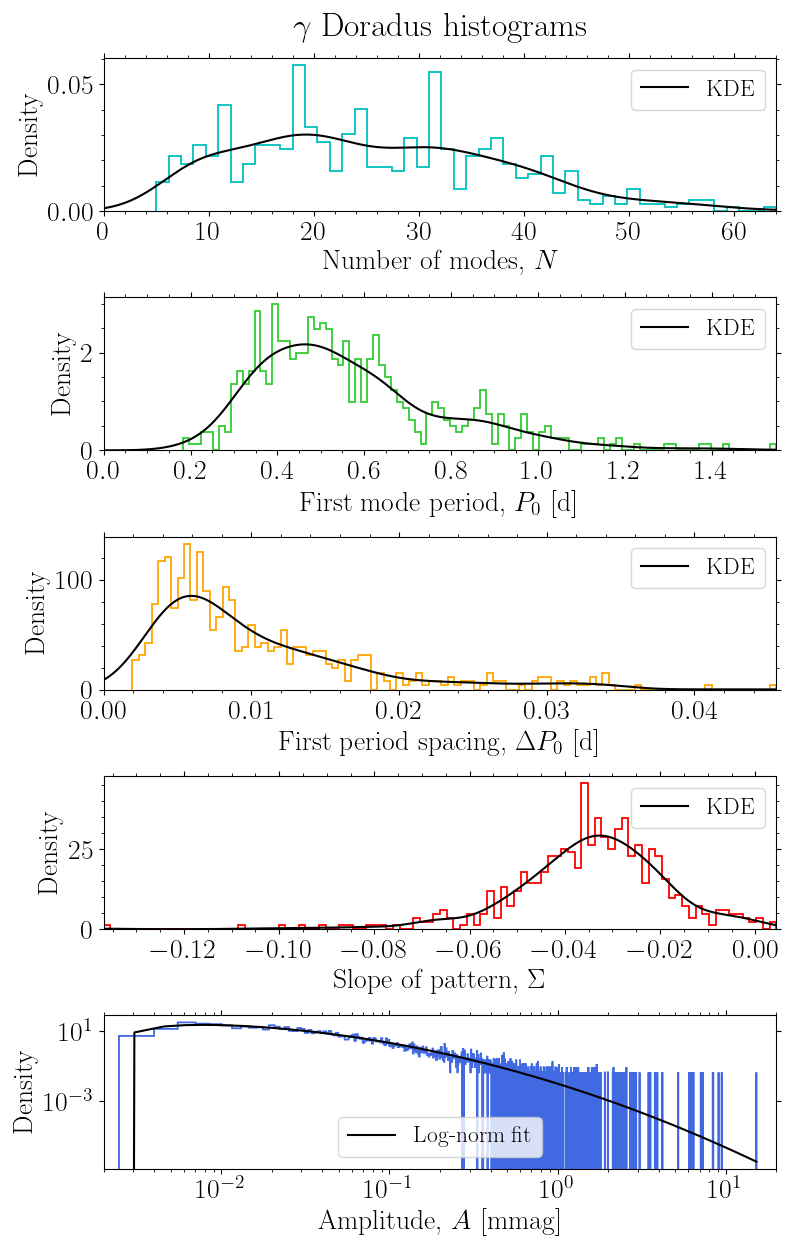

In [244]:
# Histograms
grid, panels = 10000, 5
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(dm.N, bins=50, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dm.P0, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
P0_range = np.linspace(0, h[1].max(), grid)
P0_kde_hist = P0_kde(P0_range)
ax[1].plot(P0_range, P0_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, P0_range.max())
ax[1].set_xlabel(r'First mode period, $P_0$ [d]')

h = ax[2].hist(dm.dP0, bins=100, histtype='step', density=True, ec='orange', lw=1.3)
dP0_range = np.linspace(0, h[1].max(), grid)
dP0_kde_hist = dP0_kde(dP0_range)
ax[2].plot(dP0_range, dP0_kde_hist, 'k-', label='KDE')
ax[2].set_xlim(0, dP0_range.max())
ax[2].set_xlabel(r'First period spacing, $\Delta P_0$ [d]')

h = ax[3].hist(dm.slope, bins=100, histtype='step', density=True, ec='red', lw=1.3)
slope_range = np.linspace(h[1].min(), h[1].max(), grid)
slope_kde_hist = slope_kde(slope_range)
ax[3].plot(slope_range, slope_kde_hist, 'k-', label='KDE')
ax[3].set_xlim(slope_range.min(), slope_range.max())
ax[3].set_xlabel(r'Slope of pattern, $\Sigma$')

ax[4].hist(A, bins=10000, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[4].plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax[4].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[4].set_ylabel('Density')
ax[4].set_xscale('log')
ax[4].set_yscale('log')
ax[4].set_xlim(2e-3, 20)

ax[0].set_title(r'$\gamma$ Doradus histograms', pad=15)
for i in range(panels): 
    ax[i].set_ylabel('Density')
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_gdor.png', bbox_inches='tight', dpi=200)

In [182]:
# # Check that drawing from distributions matches weights
# N = len(da.amp)
# x_val = da.amp / 1e3
# x_ran = np.linspace(x_val.min(), x_val.max(), bins)
# param = ss.lognorm.fit(x_val)
# x_fit = ss.lognorm.pdf(x_ran, param[0], loc=param[1], scale=param[2])
# x = np.zeros(N)
# for i in range(N):
#     x[i] = pd.Series(x_ran).sample(1, weights=x_fit).to_numpy()

# M = 30
# y = np.zeros(M)
# for i in range(M):
#     y[i] = pd.Series(x_ran).sample(1, weights=x_fit).to_numpy()
    
# # Inspect uncertainties
# fig, ax = plt.subplots(1,1, figsize=(8,4))
# ax.hist(x, bins=1000)
# ax.hist(y, bins=1000, histtype='step', density=True, ec='c')
# ax.plot(x_ran, x_fit, 'k-')
# ax.set_xlabel('Amplitude [mmag]')
# ax.set_ylabel('Count')
# ax.set_yscale('log')
# # ax.set_xlim(0, 1)
# # ax.set_ylim(0.01, 25)
# plt.tight_layout()

In [245]:
# Use correct stellar rotation (slope) from fit
def func(x, a, b, c, d, e):
    return  a * np.exp(-b * x) + c * np.log10(d * x) + e
P0_range  = np.linspace(dm.P0.min(), dm.P0.max(), 100)
popt, pcov = curve_fit(func, dm.P0, dm.slope)

# Fit coefficients used by varsim
print(popt)

[0.47980586 1.27007297 0.44030565 0.11122096 0.26489501]


<IPython.core.display.Javascript object>


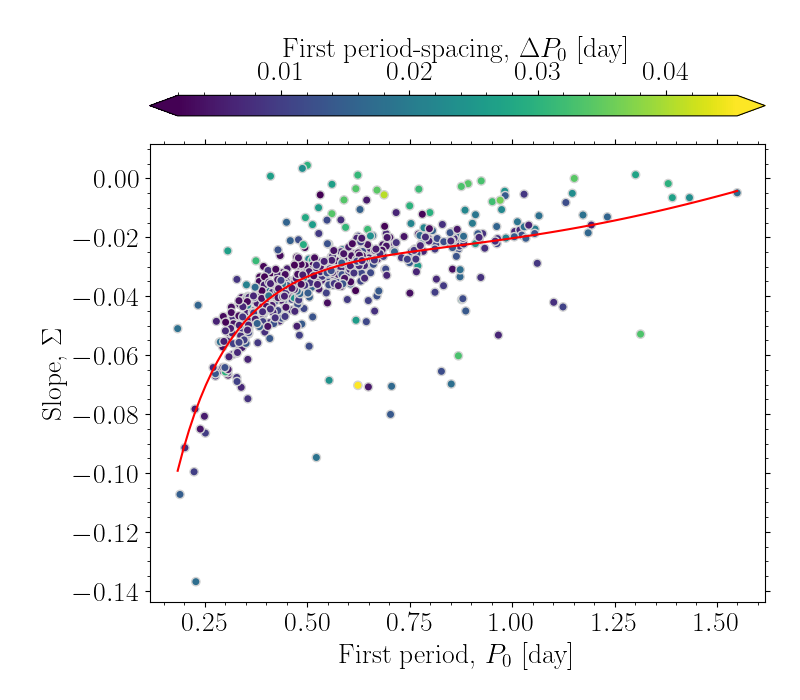

In [246]:
# Plot period spacing pattern
fig, ax = plt.subplots(1, 1, figsize=(8,7))

im0 = ax.scatter(dm.P0, dm.slope, c=dm.dP0, edgecolors='lightgray', cmap='viridis')
ax.plot(P0_range, func(P0_range, *popt), 'r-')
ax.set_xlabel('First period, $P_0$ [day]')
ax.set_ylabel('Slope, $\Sigma$')
cbar = plt.colorbar(im0, orientation='horizontal', location='top', extend='both', aspect=30)
cbar.set_label(r"First period-spacing, $\Delta P_0$ [day]", labelpad=3)                                    
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/gdor_dipole_mode_correlation.png', bbox_inches='tight', dpi=200)

In [241]:
np.arange(0,10,1)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

17


<IPython.core.display.Javascript object>


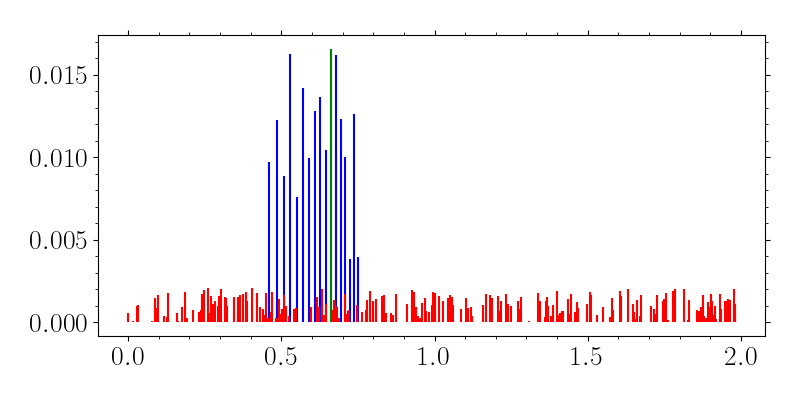

In [260]:
#----- Modes in pattern

# Select number modes
N_ran = np.arange(dm.N.min(), dm.N.max(), 1)
N = pd.Series(N_ran).sample(1, weights=N_kde(N_ran)).to_numpy()[0]
# N = np.random.randint(20, 40) 
N = int(N)
print(N)

# Select maximum period from KDE
P0_ran = np.linspace(dm.P0.min(), dm.P0.max(), 1000)
P0 = pd.Series(P0_ran).sample(1, weights=P0_kde(P0_ran)).to_numpy()[0]

# First period spacing in pattern from KDE
dP0_ran = np.linspace(dm.dP0.min(), dm.dP0.max(), 1000)
dP0 = pd.Series(dP0_ran).sample(1, weights=dP0_kde(dP0_ran)).to_numpy()[0]

# First period spacing in pattern from KDE
slope = func(P0, *popt)

# Create period-spacing pattern
P_i = np.array([dP0 * ((1 + slope)**i - 1)/slope + P0 for i in range(N)])

# Draw amplitude below maximum
A_i_ran = np.linspace(dm.A_max.min(), dm.A_max.max(), 1000)
# A_i = pd.Series(A_i_ran).sample(N, weights=A_max_kde(A_i_ran)).to_numpy()
param = [1.3177087487666639, 0.0021808585006446645, 0.03156249403328485]
A_i_fit = ss.lognorm.pdf(A_i_ran, param[0], loc=param[1], scale=param[2])
A_i = pd.Series(A_i_ran).sample(N, weights=A_i_fit).to_numpy()


# Max peak amplitude
n_max = np.argmax(A_i)
A_max0 = A_i[n_max]

# Swap max peak location with offset
n_off = np.random.randint(-5, 5)
n_dex = int(N/2 + n_off)
A_i[n_max] = A_i[n_dex]
A_i[n_dex] = A_max0

#----- Noise peaks

# Draw random periods not part of the pattern
M = np.random.randint(100, 300)
P_puls_i = np.random.uniform(0, 2, size=M)
A_puls_i = np.random.uniform(0, A_max0/8, size=M)

#----- Plot periodogram

fig, ax = plt.subplots(1,1, figsize=(8,4))
for i in range(N):
    ax.vlines(x=P_i[i], ymin=0, ymax=A_i[i], colors='b', label='Pattern')
for i in range(M):
    ax.vlines(x=P_puls_i[i], ymin=0, ymax=A_puls_i[i], colors='r', label='Extra pulsations')
ax.vlines(x=P_i[n_dex], ymin=0, ymax=A_i[n_dex], colors='g', label='Max puls')
plt.tight_layout()
plt.show()

---
## $\delta$ Scuti stars (Bowman+2018)
---

In [232]:
# Units from file: freq [c/d], ampl [mmag]
filenames = glob.glob(f'{vdir}/varsource_dsct_bowman2018/*.txt')
N = len(filenames)
N_mode = np.zeros(N)
df = pd.DataFrame()
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    df_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    df = pd.concat([df, df_i])
    N_mode[i] = df.shape[0]

# Remove very low frequencies
df = df[~(df.freq < 3)]
df.ampl /= 1e3
    
# Generate data to be used in varsim
df = df.reset_index(drop=True)
df.to_feather(f'{vdir}/varsim_mocka_dsct_bowman2018.ftr')
df.head()

 99%|█████████████████████████████████████████████████▋| 185/186 [00:00<00:00, 8


,niter,freq,freq_err,ampl,ampl_err,phase,phase_err,snr
0,1,12.977131,0.000167,0.002622,0.022986,-4.9433,0.5455,24.76
1,2,14.624146,0.000299,0.001511,0.021630,0.1102,0.9755,15.82
2,3,12.621130,0.000319,0.001312,0.020576,2.9511,1.0420,34.20
3,4,17.705925,0.000309,0.001220,0.019590,0.9454,1.0080,23.30
4,5,10.519032,0.000336,0.001145,0.018684,3.7809,1.0955,10.46


In [236]:
# Compute KDEs
N_kde = scipy.stats.gaussian_kde(N_mode)
f_kde = scipy.stats.gaussian_kde(df.freq)

# Log-norm fit to amplitudes
A = df.ampl * 1e3
A_range = np.linspace(0, A.max(), grid)
param = ss.lognorm.fit(A) # fit the sample data
A_lognorm = ss.lognorm.pdf(A_range, param[0], loc=param[1], scale=param[2])

# Fit coefficient used by varsim
np.array(param) / 1e3

array([1.29232429e-03, 6.51132626e-06, 3.79200243e-04])

<IPython.core.display.Javascript object>


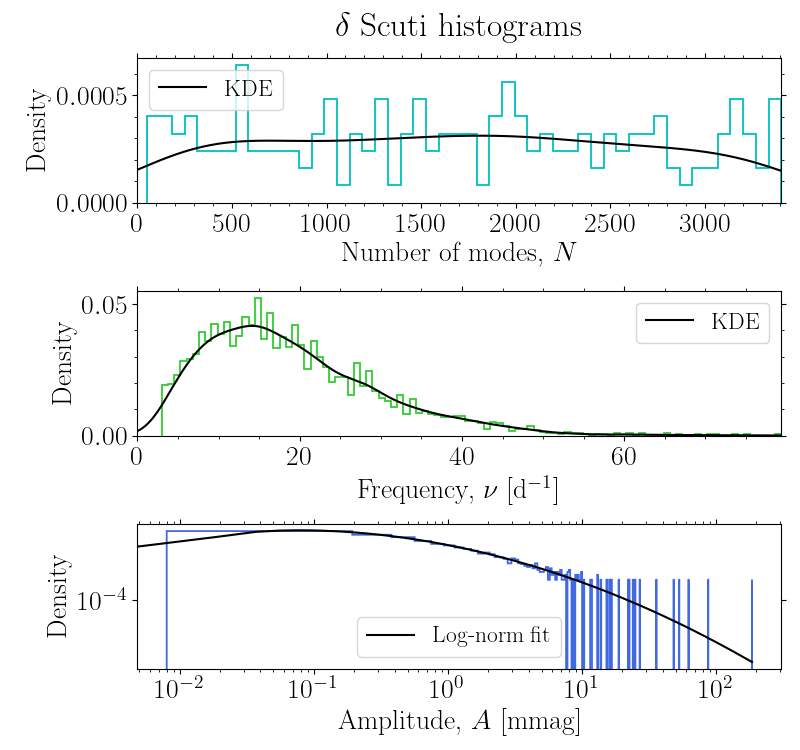

In [237]:
# Histograms
grid, panels = 10000, 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_mode, bins=50, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(df.freq, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
f_kde_hist = f_kde(f_range)
ax[1].plot(f_range, f_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A, bins=1000, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
# ax[2].set_xlim(0, 0.02)
# ax[2].set_ylim(0.1, 1e4)

ax[0].set_title(r'$\delta$ Scuti histograms', pad=15)
for i in range(panels): 
    ax[i].set_ylabel('Density')
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


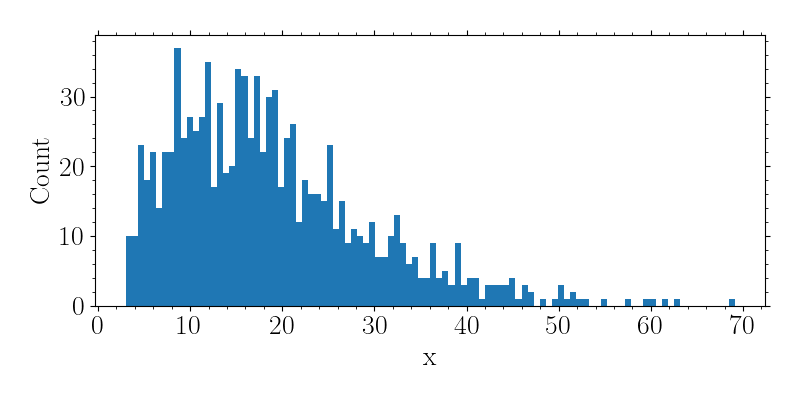

In [238]:
# Check that drawing from distributions matchs weights
x_val = df.freq
x_kde = f_kde

N = 1000
x_ran = np.linspace(x_val.min(), x_val.max(), N)
x = np.zeros(N)
for i in range(N):
    x[i] = pd.Series(x_ran).sample(1, weights=x_kde(x_ran)).to_numpy()
    
# Plot distribution
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(x, bins=100)
ax.set_xlabel('x')
ax.set_ylabel('Count')
plt.tight_layout();

In [48]:
# Select number modes
N = np.random.randint(20, 40)

# Select fundamental mode
f_ran = np.linspace(df.freq.min(), df.freq.max(), 1000)
f_i = pd.Series(f_ran).sample(N, weights=f_kde(f_ran)).to_numpy()
f_i

array([ 6.60469561, 21.6557101 , 17.45365022, 15.69642517,  5.84068472,
       23.79494059, 33.11587342, 14.09200231, 34.10908758, 12.41117836,
       25.55216563,  7.59790976, 41.29078992,  4.15986076, 16.38403497,
       10.57755222, 22.19051772, 15.77282626, 20.05128724,  6.29909125,
       27.99700047, 32.35186253,  8.74392609, 37.92914202, 22.72532534,
       41.36719101, 24.55895148, 22.03771554, 13.32799142, 30.74743967])

In [52]:
# Use pulsation constant Q to get overtones
logg = 4.5
Mbol = 4.74
Teff = 6000

logP = np.zeros(N)
for i in range(N):
    Q = np.random.uniform(0.022, 0.033)
    logP[i] = np.log10(Q) - 1/2*logg - 1/10*np.log10(Mbol) - np.log10(Teff) + 6.454

In [59]:
P10 = 10 #0.756
logg = 4.5
Mbol = 4.74
Teff = 6000
logQ = np.log10(P10) + logg/2 + np.log10(Mbol)/10 + np.log10(Teff) - 6.454
logQ

0.641729084551053

In [61]:
Q = 0.6
logg = 4.5
Mbol = 4.74
Teff = 6000
logP = np.log10(Q) - logg/2 - np.log10(Mbol)/10 - np.log10(Teff) + 6.454
logP

0.1364221658325908

---
## RR Lyrae stars (Bodi)
---

In [4]:
filenames = glob.glob(f'{vdir}/varsource_rrly_bodi2023/*.fou')

In [6]:
dv_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    dv = pd.concat([dv, dv_i])

1545

In [ ]:
dv = pd.DataFrame()
for f in tqdm(filenames, bar_format=ut.tqdmBar()):
    dv_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    dv = pd.concat([dv, dv_i])

---
## $\beta$ Cephei stars (Conny)
---

In [74]:
filenames = glob.glob(f'{vdir}/varsource_bcep_conny2024/*.scargle')

In [82]:
# Load all files into one data frame
skip = [5, 6, 54, 59, 76, 77, 82, 129, 131, 133, 149, 163, 165, 166, 185, 190, 194]
dv = pd.DataFrame()
for f in tqdm(filenames, bar_format=ut.tqdmBar()):
    if not i == skip:
        dv_i = pd.read_csv(filenames[0], skiprows=22, sep='           ', names=['freq', 'ampl'])   
        dv = pd.concat([dv, dv_i])

100%|██████████████████████████████████████████████████| 196/196 [03:37<00:00,  


,freq,ampl
0,0.000000,NaN
1,0.000100,0.00015455
2,0.000200,0.00015455
3,0.000300,0.00015456
4,0.000400,0.00015456
...,...,...
199996,19.999599,0.00011329
199997,19.999699,0.00011379
199998,19.999799,0.00011428
199999,19.999899,0.00011477


In [83]:
df = dv

In [ ]:
df = dv
# mag -> mmag
da.amp *= 1e3
dm.A_max *= 1e3

# Generate KDEs
N_kde    = scipy.stats.gaussian_kde(dm.N)
freq_kde = scipy.stats.gaussian_kde(dm.P0)
ampl_kde = scipy.stats.gaussian_kde(dm.A_max)

<IPython.core.display.Javascript object>


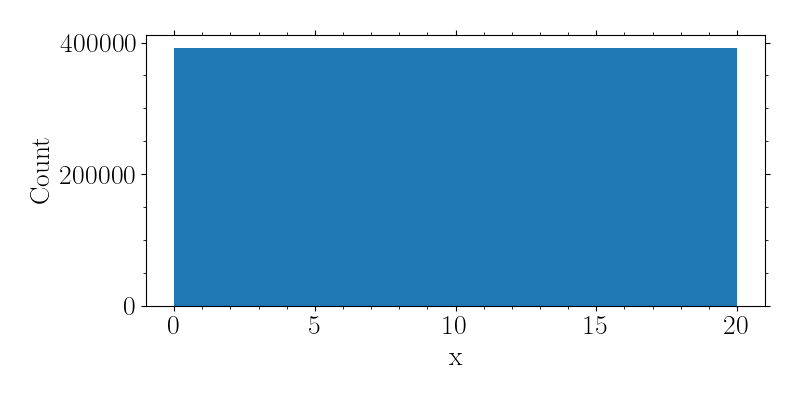

In [84]:
# Plot distribution
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(df.freq, bins=100)
ax.set_xlabel('x')
ax.set_ylabel('Count')
plt.tight_layout();

---
## Stellar flares
---

<IPython.core.display.Javascript object>


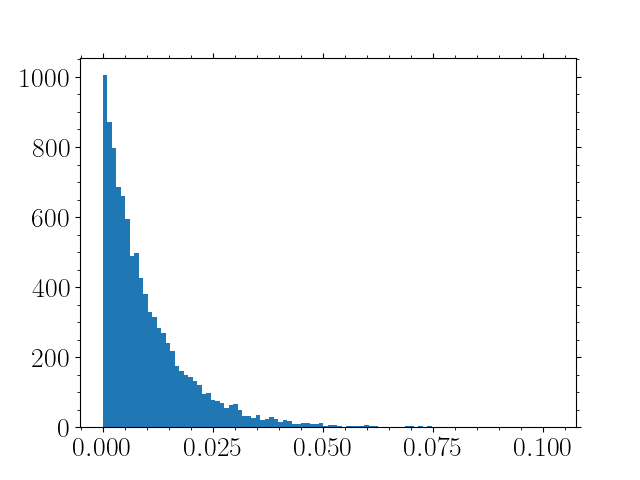

array([0.15799157, 0.2282505 , 0.07268456])

In [43]:
rng = ut.rng()
x = rng.exponential(0.01, 10000)
y = rng.exponential(0.1, 3)
plt.figure()
plt.hist(x, bins=100);
y

<IPython.core.display.Javascript object>


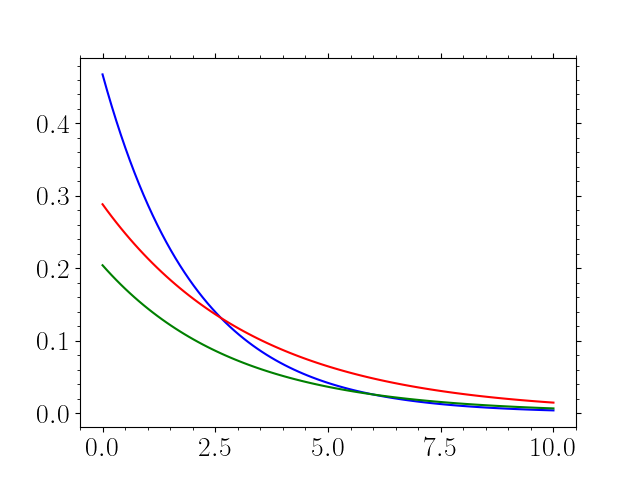

In [51]:
a_rate_F, b_rate_F = -0.21, -0.33
a_rate_G, b_rate_G = -0.15, -0.69
a_rate_K, b_rate_K = -0.13, -0.54
x = np.linspace(0, 10, 100)
rate_F = a_rate_F * x + b_rate_F
rate_G = a_rate_G * x + b_rate_G
rate_K = a_rate_K * x + b_rate_K

plt.figure()
plt.plot(x, 10**rate_F, 'b-')
plt.plot(x, 10**rate_G, 'g-')
plt.plot(x, 10**rate_K, 'r-')

<IPython.core.display.Javascript object>


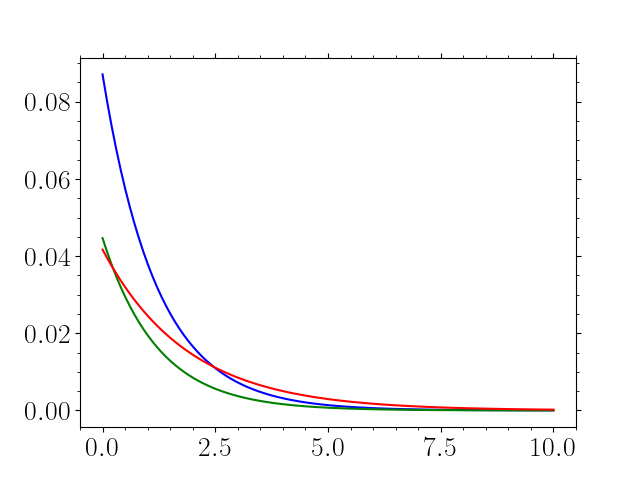

In [50]:
a_A_F, b_A_F = -0.36, -1.06 
a_A_G, b_A_G = -0.36, -1.35 
a_A_K, b_A_K = -0.23, -1.38 

x = np.linspace(0, 10, 100)
A_F = a_A_F * x + b_A_F
A_G = a_A_G * x + b_A_G
A_K = a_A_K * x + b_A_K

plt.figure()
plt.plot(x, 10**A_F, 'b-')
plt.plot(x, 10**A_G, 'g-')
plt.plot(x, 10**A_K, 'r-')